# 06 · 三类电场与焦点尺寸：人工检查（PSF=0）

## 阅读目标

本 Notebook **不会运行电子输运**。可以在尚未安装 Geant4、尚未产生正式结果时从头执行。
交付版本只含静态电场与几何分辨率输出；它们不是电子 shadow 模拟结果。
实际结果缺失时会明确提示，不用零图或测试数据代替。

阅读顺序：配置与来源 → 静态电场 → 几何分辨率 → 已有 shadow → 分类/子样本 → 焦点/探测距对照。
完整安装与计算命令见 `docs/linux_field_study.md`。不要用旧的 `execute_notebooks.py` 执行全部 Notebook，
其中其他 Notebook 可能会启动输运。

## 1. 配置、来源和状态

### 关键假设

R=50 μm，3 MeV，L1=10 mm，主组 L2=2000 mm；焦点 FWHM=10/5/1 μm；单轴 RMS 束散固定 10 mrad。
固定束散缩小焦点意味着发射度降低。PSF=0 **只关闭探测器空间展宽**，25 μm 像素积分、水中散射和源尺寸仍保留。
分子层是等效势差模型，不是分子瞬时场；PB 半衰减深度不是 Debye 长度。相同种子不能保证跨平台逐事件相同。

下面可修改 `OUTPUT` 指向 Linux 计算结果目录；项目路径自动从当前目录向上寻找，不使用 Mac 的绝对路径。

In [1]:
from pathlib import Path
import json
import html
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Image

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'src/droplet_shadow').is_dir()), None)
if ROOT is None:
    raise RuntimeError('请从项目根目录或 notebooks 目录打开本 Notebook。')
sys.path.insert(0, str(ROOT / 'src'))
from droplet_shadow.study import load_study, completed_path, sha256
from droplet_shadow.study_analysis import field_figure
from droplet_shadow.analysis import spatial_resolution_object_um

OUTPUT = ROOT / 'results/field_scale_study'
CASES = load_study(ROOT / 'examples/field_scale_study/manifest.json')
BY_ID = {c.case_id: c for c in CASES}
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10, 'figure.dpi': 110})

def table(headers, rows):
    # 不需要 pandas；只展示原始数值/状态，不自动推断是否可见。
    tags = '<tr>' + ''.join('<th>'+html.escape(str(h))+'</th>' for h in headers) + '</tr>'
    tags += ''.join('<tr>'+''.join('<td>'+html.escape(str(v))+'</td>' for v in row)+'</tr>' for row in rows)
    display(HTML('<table>'+tags+'</table>'))

states = []
for c in CASES:
    state_file = OUTPUT / c.case_id / 'state.json'
    status = json.loads(state_file.read_text()).get('status', 'unknown') if state_file.exists() else 'not_run'
    states.append((c.case_id, c.group, c.config.source.crossover_fwhm_um, c.config.run.n_simulated, status))
table(['条件', '分组', '焦点 FWHM (μm)', '初级电子数', '记录状态（非重新验收）'], states)
print('正式条件:', len(CASES), '；计划初级电子总数:', sum(c.config.run.n_simulated for c in CASES))

条件,分组,焦点 FWHM (μm),初级电子数,记录状态（非重新验收）
absent_s10_l2000,main,10,10000000,not_run
neutral_s10_l2000,main,10,10000000,not_run
dipole_0p5nm_s10_l2000,main,10,10000000,not_run
pb_0p01uM_s10_l2000,main,10,10000000,not_run
pb_0p1uM_s10_l2000,main,10,10000000,not_run
pb_1uM_s10_l2000,main,10,10000000,not_run
q_plus_1e6_s10_l2000,main,10,10000000,not_run
q_minus_1e6_s10_l2000,main,10,10000000,not_run
absent_s5_l2000,main,5,10000000,not_run
neutral_s5_l2000,main,5,10000000,not_run


正式条件: 35 ；计划初级电子总数: 350000000


In [2]:
sources = json.loads((ROOT / 'data/field_scale_sources.json').read_text(encoding='utf-8'))
table(['来源', 'DOI', 'PDF 页', '适用限制'],
      [(key, value['doi'], value['pages'], value['limitation']) for key, value in sources['references'].items()])
print('完整参数来源、假设及单位换算：data/field_scale_sources.json')

来源,DOI,PDF 页,适用限制
hao2022,10.1038/s41467-021-27941-x,"[2, 3]",4–8 nm 半径的分子模拟。表面势包含 mean inner potential；不能原样当作 50 μm 滴的均匀单调偶极壳。
xiong2020,10.1021/acs.jpclett.0c02061,[3],直径约 4–20 μm；不是水/真空界面的长程外场，不独立叠加为另一套分子场。
chamberlayne2020,10.1063/5.0006550,"[2, 3, 4]",原文示例直径 20 μm；本研究重新按 100 μm 直径计算离子数。0.01/0.1 μM 为本研究扩展情景，不称为原文测量值。
heindel2024,10.1038/s41467-024-47879-0,"[1, 3]",4 nm 纳米滴及其尺度讨论不等于本研究 50 μm 半径液滴的化学阈值；本项目不判断反应加速因果。


完整参数来源、假设及单位换算：data/field_scale_sources.json


## 2. 各模型的静态电场

以下只求解析场/PB 边值问题，不追踪电子。每个模型独立成图，横纵轴均为线性。
左列覆盖整体半径，右列对界面额外加密；场是带符号的径向分量，不是 |E|。
虚线表示液滴表面。中性层外场为零不代表穿透电子不受影响，更不排除微观强场。
图中情景的来源与假设见上表。

### dipole_0p5nm

Hao 2022 启发的等效 1 V/0.5 nm 层；厚度/形状是假设，不是瞬时分子场。


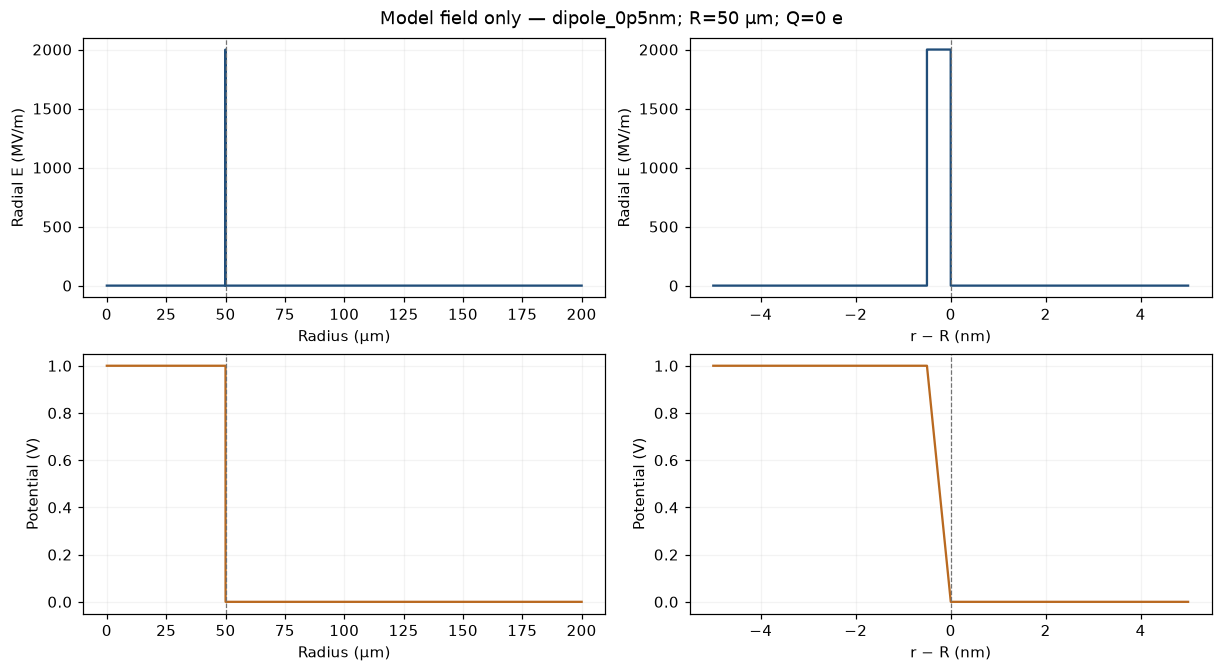

In [3]:
case = BY_ID['dipole_0p5nm_s10_l2000']
print(case.note)
fig = field_figure(case)
plt.show()
plt.close(fig)

### dipole_1nm

相同等效势差 1 V、厚度改为 1 nm；隔离厚度变化的对照。


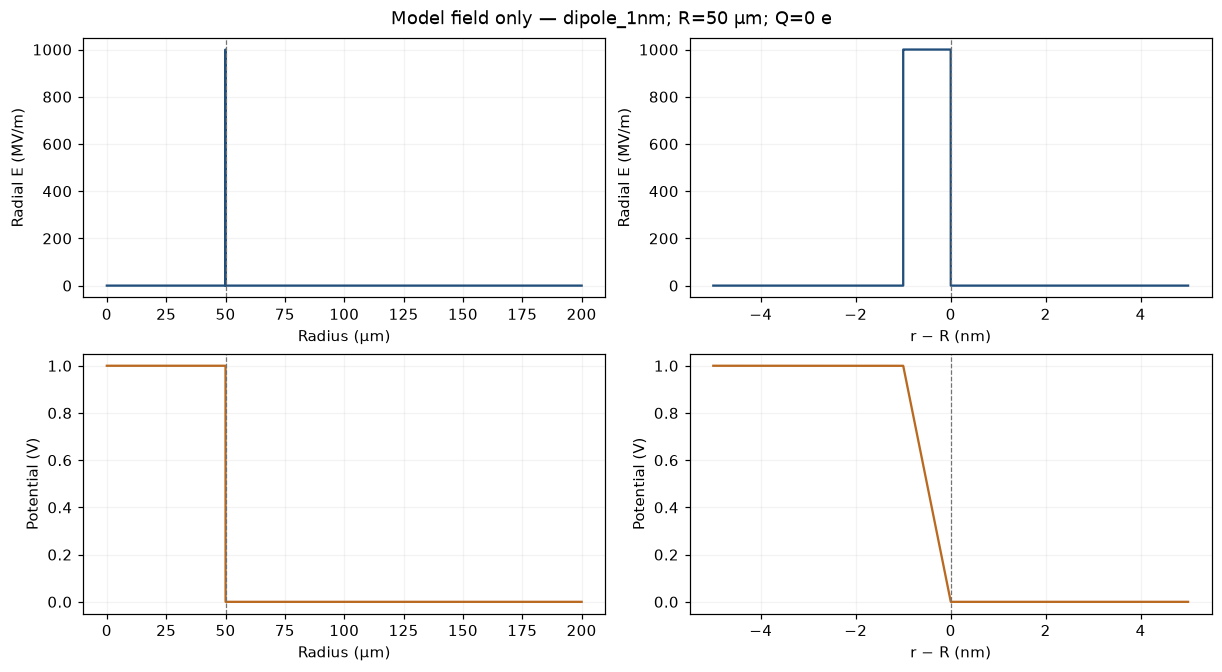

In [4]:
case = BY_ID['dipole_1nm_s10_l2000']
print(case.note)
fig = field_figure(case)
plt.show()
plt.close(fig)

### shell_10nm

规定 ±10^8 e 同心双壳；总电荷抵消而非面密度相等，不是 PB 平衡解。


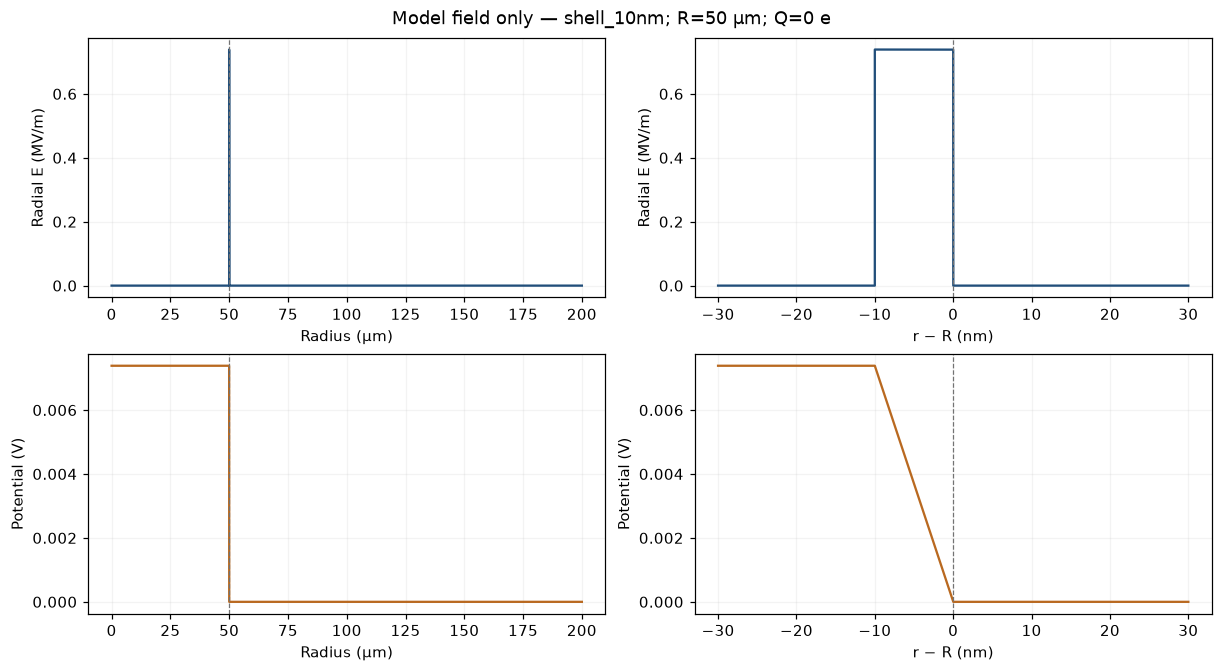

In [5]:
case = BY_ID['shell_10nm_s10_l2000']
print(case.note)
fig = field_figure(case)
plt.show()
plt.close(fig)

### pb_0p01uM

球对称 PB；平均未配对正离子 0.01 μmol/L；固定负表面电荷严格中和。


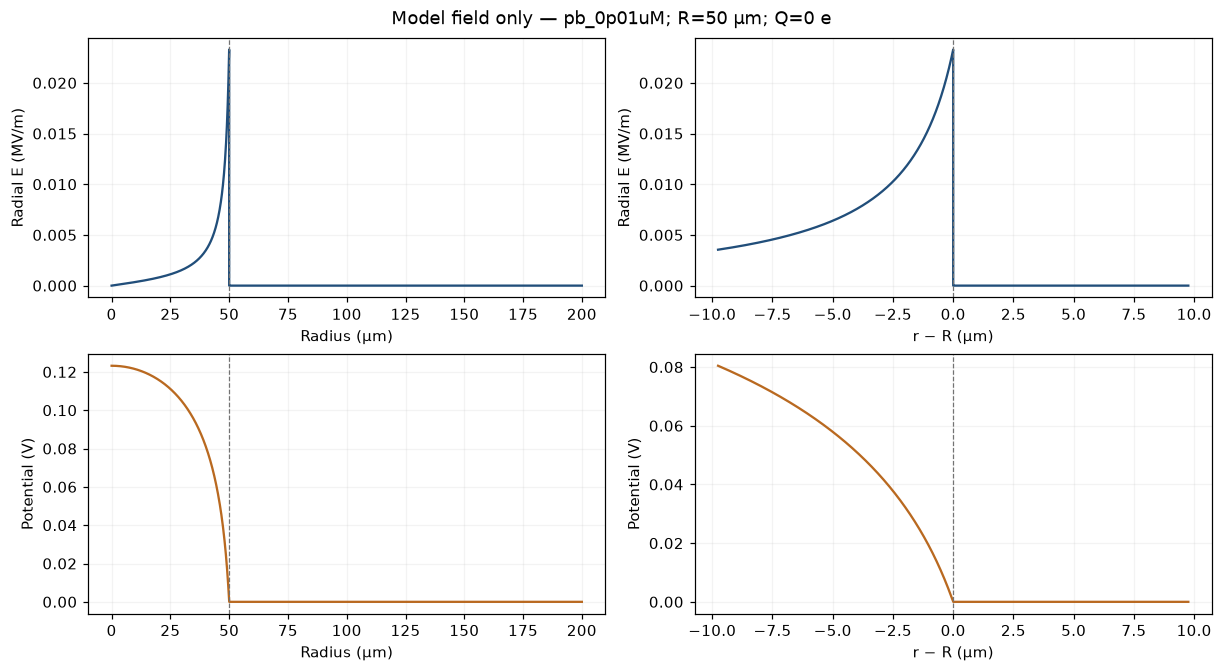

In [6]:
case = BY_ID['pb_0p01uM_s10_l2000']
print(case.note)
fig = field_figure(case)
plt.show()
plt.close(fig)

### pb_0p1uM

球对称 PB；平均未配对正离子 0.1 μmol/L；固定负表面电荷严格中和。


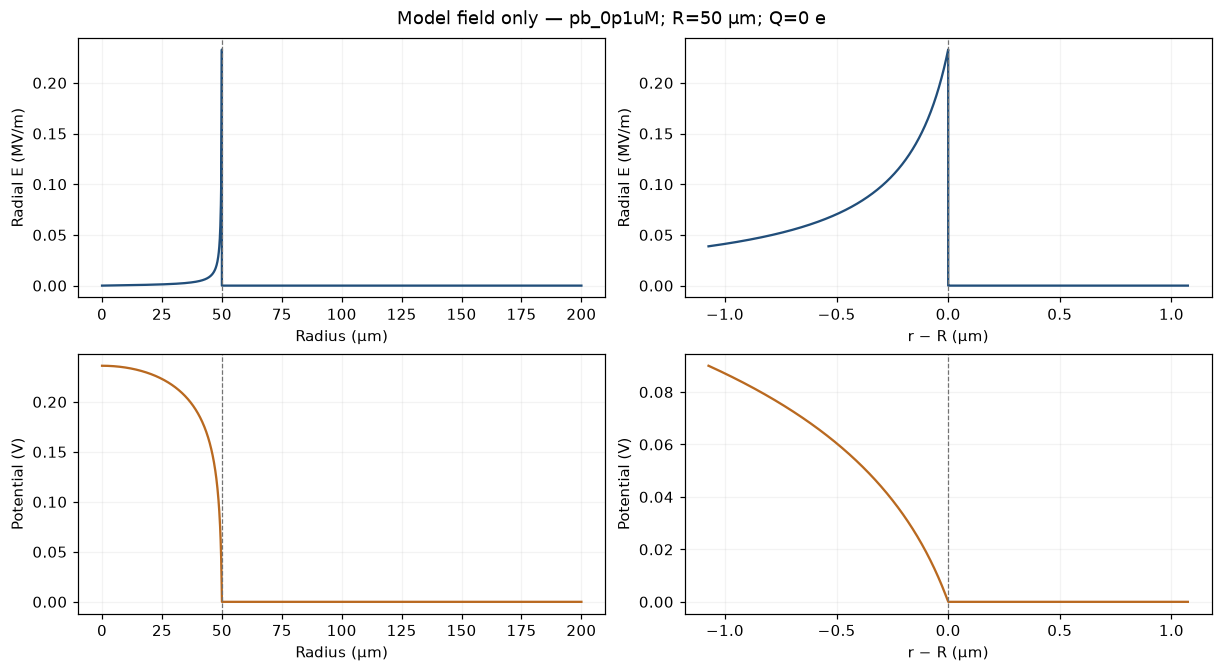

In [7]:
case = BY_ID['pb_0p1uM_s10_l2000']
print(case.note)
fig = field_figure(case)
plt.show()
plt.close(fig)

### pb_1uM

球对称 PB；平均未配对正离子 1 μmol/L；固定负表面电荷严格中和。


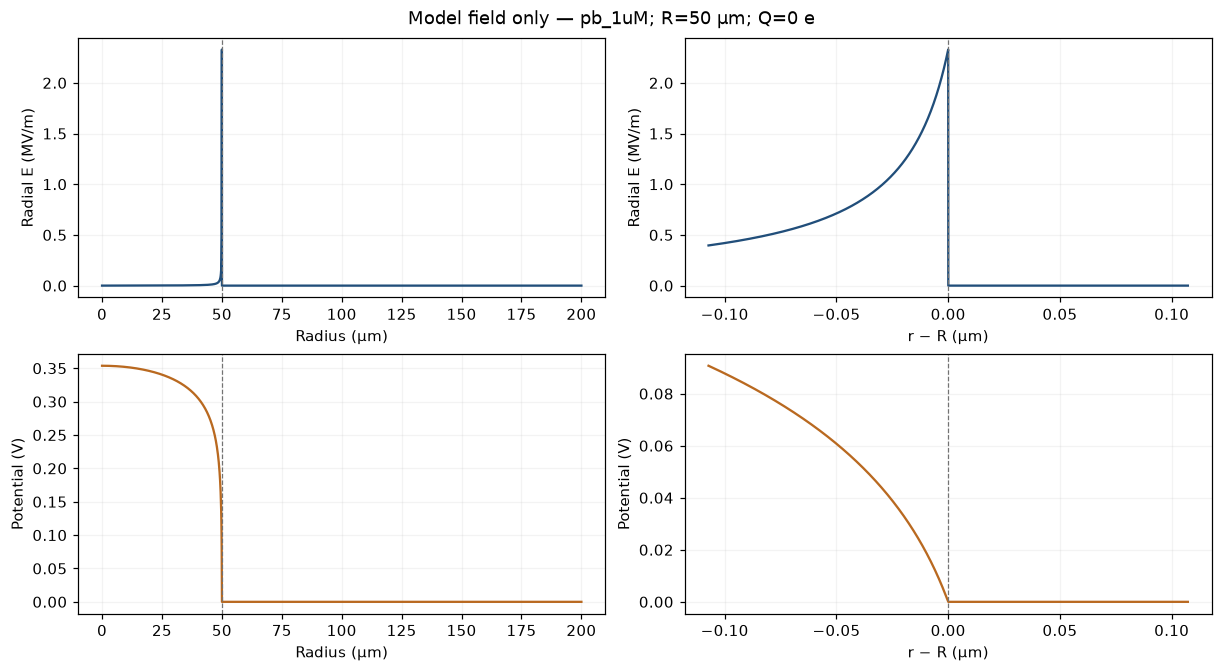

In [8]:
case = BY_ID['pb_1uM_s10_l2000']
print(case.note)
fig = field_figure(case)
plt.show()
plt.close(fig)

### q_plus_1e6

规定的均匀表面净电荷 +10^6 e；不是文献实测。


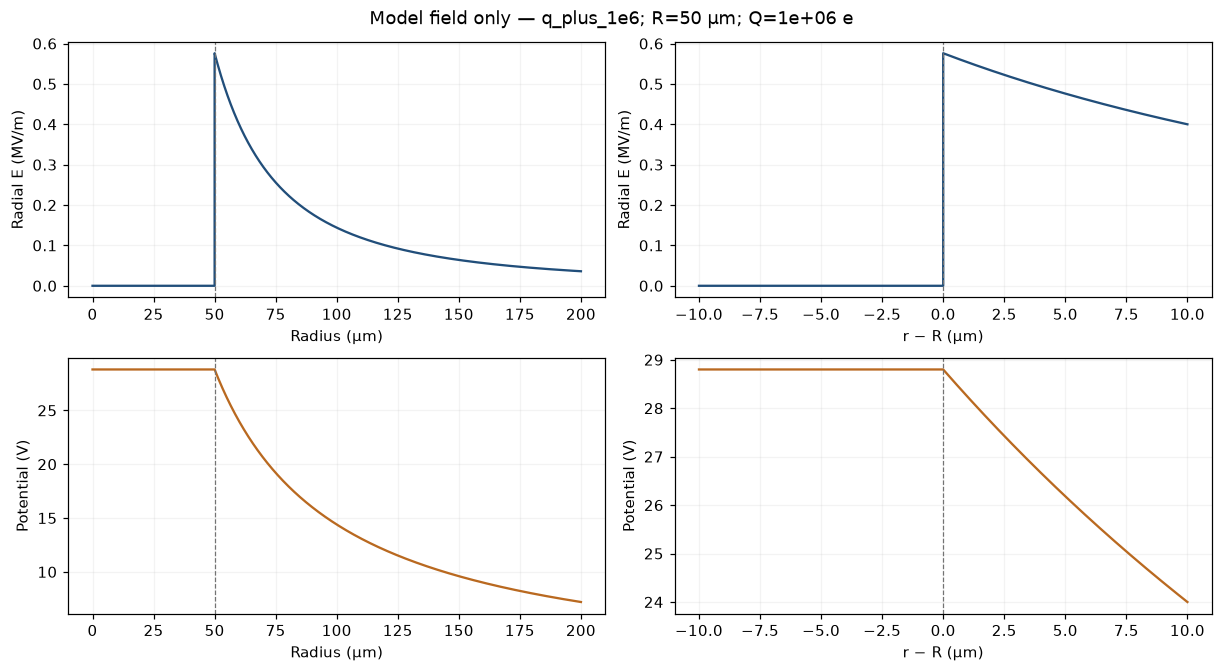

In [9]:
case = BY_ID['q_plus_1e6_s10_l2000']
print(case.note)
fig = field_figure(case)
plt.show()
plt.close(fig)

### q_minus_1e6

规定的均匀表面净电荷 -10^6 e；不是文献实测。


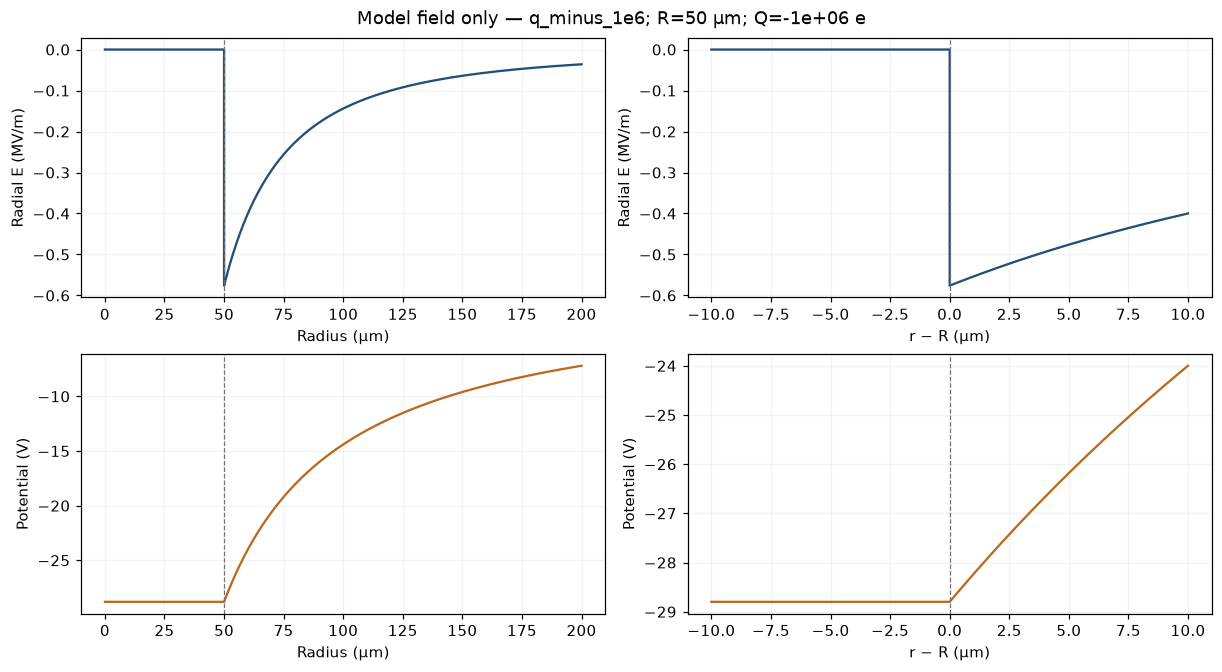

In [10]:
case = BY_ID['q_minus_1e6_s10_l2000']
print(case.note)
fig = field_figure(case)
plt.show()
plt.close(fig)

## 3. 几何分辨率与像素

此处是有限源和像素均匀积分的 RMS 合成，再乘 2.355 报等效 FWHM。
不是能否检测电场的判据，也不包含水中散射造成的对比度损失。
不把检测到一个未分辨薄层的积分信号解释成分辨了其纳米厚度。

In [11]:
table(['焦点 FWHM (μm)', 'M', '像素物方宽度 (μm)', '物方等效 FWHM (μm)'],
      [(focus, BY_ID[f'neutral_s{focus}_l2000'].config.geometry.magnification,
        25 / BY_ID[f'neutral_s{focus}_l2000'].config.geometry.magnification,
        spatial_resolution_object_um(BY_ID[f'neutral_s{focus}_l2000'].config))
       for focus in (10, 5, 1)])

焦点 FWHM (μm),M,像素物方宽度 (μm),物方等效 FWHM (μm)
10,201.0,0.12437810945273632,9.95060796780121
5,201.0,0.12437810945273632,4.975842762376241
1,201.0,0.12437810945273632,0.998610595447197


## 4. 读取已完成的 shadow 与分类曲线

先在 Linux 显式运行研究脚本，然后执行其 `--analyze` 模式，才会产生以下图。
Notebook 不自动补跑，也不在已有噪声图上二次加噪。
期望图仍含输运 Monte Carlo 纹理；分类径向曲线使用真实落点半径，单位为每入射初级电子、每探测器 mm²。
子样本按初级事件划分，次级与母事件一起；无落点事件仍计入分母。十条子样本曲线不是置信区间。

In [12]:
CASE_ID = 'dipole_0p5nm_s10_l2000'  # 可改为清单中的任意条件
case = BY_ID[CASE_ID]
analysis_dir = OUTPUT / 'analysis' / CASE_ID
attempt = completed_path(case, OUTPUT, verify_hashes=False)
metadata_file = analysis_dir / 'analysis.json'
ready = False
if attempt is None or not metadata_file.exists():
    print('尚无已完成且后处理的该组数据。不启动计算。')
else:
    metadata = json.loads(metadata_file.read_text())
    state = json.loads((OUTPUT / CASE_ID / 'state.json').read_text())
    ready = (metadata['config'] == case.config.to_dict() and
             metadata['input_hits_sha256'] == state['sha256']['hits.npz'])
    print('派生结果与配置/登记的落点哈希匹配:', ready)
    print('本 Notebook 未重新读取全部大型 CSV 校验哈希；--resume/--analyze 会执行完整文件校验。')
if ready:
    for name in ('exposure_1000000.png', 'classified_profiles.png', 'comparison.png', 'radial_comparison.png'):
        path = analysis_dir / name
        if path.exists():
            display(Image(filename=str(path), width=1000))
        else:
            print('缺少派生图（可能未处理参照）:', name)

尚无已完成且后处理的该组数据。不启动计算。


## 5. 焦点、探测距与曝光检查

同一焦点对照图使用共同色标；第二排是模型减同焦点无电场水滴，未经额外平滑。
500 mm 对照保存在对应 `_l500` 条件下，不能直接与 2000 mm 图逐像素相减，因为放大率不同。
改变曝光只重用已有落点；对 Q=0 的情况，电荷变化比值不可定义，不应填为 0。

In [13]:
focus_path = OUTPUT / 'analysis/focus' / (case.model + '.png')
if ready and focus_path.exists():
    for suffix in ('', '_edge', '_radial'):
        path = focus_path.with_name(case.model + suffix + '.png')
        if path.exists():
            display(Image(filename=str(path), width=1000))
        else:
            print('缺少焦点比较图:', path.name)
else:
    print('三种焦点的完整比较尚未生成。')
if ready:
    table(['入射曝光', '期望信号总和', '曝光预计改变电荷 (e)', '|ΔQ|/|Q|'],
          [(key, value['expected_signal_sum'], value['projected_charge_change_e'],
            value['projected_abs_charge_change_over_abs_Q'])
           for key, value in metadata['exposures'].items()])

三种焦点的完整比较尚未生成。


## 6. 人工检查清单与下一步

- 核对净电荷、界面层厚度、介电常数和场方向；不要仅比较最大场强。
- 区分源尺寸模糊、像素积分、材料散射与有限 MC 波动。
- 检查边缘局部及完整视野，保留通量损失；不要用各自归一化掩盖耗尽。
- 先查看无材料探针 `results/field_scale_validation/` 的收敛和能量误差，再解释微弱位移。
- 未发现外场信号不能排除强分子局域场；单张图不直接判定化学加速机制。

本 Notebook 不给出自动“可见/不可见”标签。正式输运与数值验收仍需在 Linux 上完成。
安装、只读检查、显式运行、断点恢复及后处理命令见 `docs/linux_field_study.md`。